In [ ]:
from pathlib import Path
import torch 
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from constants import DATA_DIR
from scripts.geometric_degrdation_helper import expand_bbox, shift_bbox, GEOM_LEVELS
from scripts.data_visualization import load_sa1b_sample
from scripts.model_helper import load_model
from tqdm import tqdm

In [ ]:
C2A = {
    "primary":  "#2E86AB",   # GT box
    "warning":  "#E84855",   # jittered box
    "success":  "#3BB273",   # predicted box
    "bg":       "#F8F9FA",
    "text":     "#212529",
}
RNG = np.random.default_rng(42)

In [3]:
def jitter(boxes_xywh, cfg, img_w, img_h):
    if cfg is None:
        return boxes_xywh
    mode, factor = cfg
    if mode == "expand":
        return [expand_bbox(b, factor, img_w, img_h) for b in boxes_xywh]
    return [shift_bbox(b, factor, img_w, img_h, rng=RNG) for b in boxes_xywh]


def xywh_to_xyxy(b):
    x, y, w, h = b
    return [x, y, x + w, y + h]


def run_inference(model, processor, img_arr, boxes_xywh, device):
    """Return (masks_np list, pred_boxes_xywh list) from SAM3 with box prompts."""
    boxes_xyxy = [xywh_to_xyxy(b) for b in boxes_xywh]
    inputs = processor(
        images=Image.fromarray(img_arr),
        input_boxes=[boxes_xyxy],          # [1, N, 4]
        return_tensors="pt",
    ).to(device, dtype=torch.float16)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=0.5,
        mask_threshold=0.5,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]

    masks     = results["masks"].cpu().numpy()          # (N, H, W)
    pred_boxes = results["boxes"].cpu().numpy().tolist() # xyxy

    # convert predicted boxes back to xywh for consistent drawing
    pred_boxes_xywh = [[x, y, x2 - x, y2 - y] for x, y, x2, y2 in pred_boxes]
    return masks, pred_boxes_xywh

def overlay_masks(ax, masks):
    """Blend all predicted masks onto the axes using a fixed colour cycle."""
    colors = [C2A["primary"], C2A["warning"], C2A["success"], "#F18F01", "#A23B72"]
    for i, mask in enumerate(masks):
        color_rgb = np.array([int(colors[i % len(colors)][j:j+2], 16)
                              for j in (1, 3, 5)]) / 255.0
        rgba = np.zeros((*mask.shape, 4))
        rgba[mask > 0] = [*color_rgb, 0.45]
        ax.imshow(rgba)


def draw_box(ax, bbox_xywh, color, lw=1.5, ls="-"):
    x, y, w, h = bbox_xywh
    ax.add_patch(mpatches.Rectangle(
        (x, y), w, h,
        linewidth=lw, edgecolor=color, facecolor="none", linestyle=ls,
    ))

In [ ]:
LEVELS = {
    "GT Prompt\n(L0)":       None,
    "Expand 10%\n(L10)":    ("expand", GEOM_LEVELS["L10"]),
    "Expand 20%\n(L20)":    ("expand", GEOM_LEVELS["L20"]),
    "Shift 10%\n(L10)":     ("shift",  GEOM_LEVELS["L10"]),
    "Shift 20%\n(L20)":     ("shift",  GEOM_LEVELS["L20"]),
}

# ---------------------------------------------------------------------------
# Load sample
# ---------------------------------------------------------------------------
data_path = Path(DATA_DIR)
stem = "sa_11177074"
img_arr,meta = load_sa1b_sample(data_path/stem)

img_h, img_w = img_arr.shape[:2]
gt_boxes = [ann["bbox"] for ann in meta.get("annotations", [])][:1]
print(f"Image: {stem}  |  size: {img_w}×{img_h}  |  GT boxes shown: {len(gt_boxes)}")

Image: sa_11177074  |  size: 2250×1500  |  GT boxes shown: 1


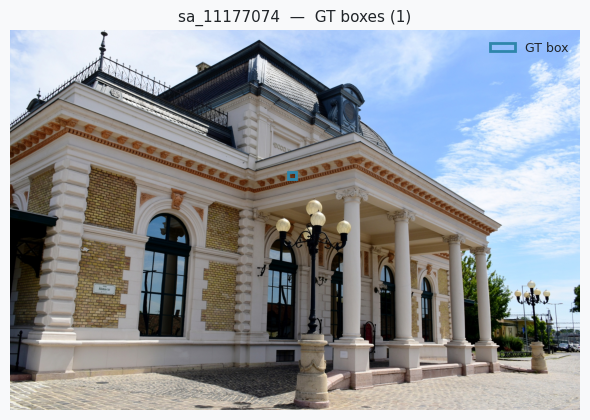

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), facecolor=C2A["bg"])
ax.imshow(img_arr)
ax.set_title(f"{stem}  —  GT boxes ({len(gt_boxes)})",
             color=C2A["text"], fontsize=11)
ax.axis("off")
for b in gt_boxes:
    draw_box(ax, b, C2A["primary"], lw=2)
handle = mpatches.Patch(edgecolor=C2A["primary"], facecolor="none",
                        label="GT box", lw=2)
ax.legend(handles=[handle], loc="upper right",
          frameon=False, fontsize=9, labelcolor=C2A["text"])
plt.tight_layout()
plt.show()

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, processor = load_model(device)

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

In [ ]:
n = len(LEVELS)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8), facecolor=C2A["bg"])
fig.suptitle(
    f"Geometric Degradation Effect on SAM3 — {stem}",
    color=C2A["text"], fontsize=13,
)

row_labels = ["Input prompt boxes", "SAM3 predicted masks"]
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, color=C2A["text"], fontsize=10)

for col, (title, cfg) in enumerate(tqdm(LEVELS.items(), desc="Levels")):
    jittered = jitter(gt_boxes, cfg, img_w, img_h)
    masks, pred_boxes = run_inference(model, processor, img_arr, jittered, device)
    torch.cuda.empty_cache()

    ax_top = axes[0, col]
    ax_top.imshow(img_arr)
    ax_top.set_title(title, color=C2A["text"], fontsize=9)
    ax_top.axis("off")
    for gt_b, jit_b in zip(gt_boxes, jittered):
        draw_box(ax_top, gt_b,  C2A["primary"], lw=1.5, ls="-")
        if cfg is not None:
            draw_box(ax_top, jit_b, C2A["warning"], lw=1.5, ls="--")

    ax_bot = axes[1, col]
    ax_bot.imshow(img_arr)
    ax_bot.axis("off")
    overlay_masks(ax_bot, masks)
    for pb in pred_boxes:
        draw_box(ax_bot, pb, C2A["success"], lw=1.5, ls="-")

    # render incrementally so each column appears as it's ready
    fig.canvas.draw_idle()
    plt.pause(0.01)

# Shared legend
handles = [
    mpatches.Patch(edgecolor=C2A["primary"], facecolor="none", label="GT box",        lw=1.5),
    mpatches.Patch(edgecolor=C2A["warning"], facecolor="none", label="Jittered box",  lw=1.5, linestyle="--"),
    mpatches.Patch(edgecolor=C2A["success"], facecolor="none", label="Predicted box", lw=1.5),
    mpatches.Patch(facecolor=C2A["primary"],  alpha=0.45,      label="Predicted mask"),
]
fig.legend(handles=handles, loc="lower center", ncol=4,
           frameon=False, fontsize=9, labelcolor=C2A["text"])
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

Levels:   0%|          | 0/5 [00:00<?, ?it/s]